In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

data = pd.read_csv("customer_churn_data.csv")

# Drop 'customerID' as it's an identifier and not a feature
X = data.drop(["Churn", "customerID"], axis=1)
y = data["Churn"]

# Convert categorical columns to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          No       0.49      0.55      0.52       584
         Yes       0.50      0.44      0.47       592

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.50      1176



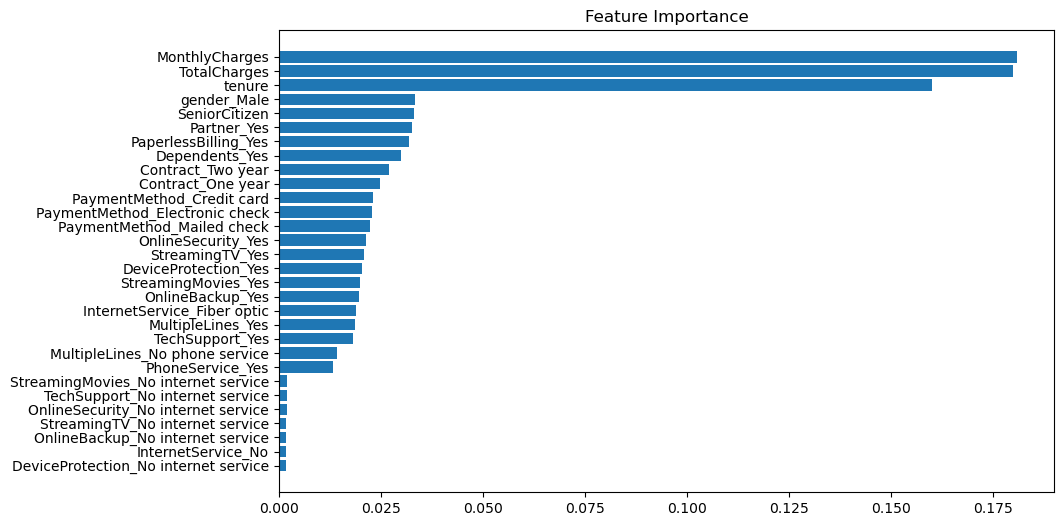

In [2]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [3]:
pip install shap lime imblearn

Note: you may need to restart the kernel to use updated packages.


Background dataset has 4704 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4704 when initializing the masker.
100%|===================| 2350/2352 [04:42<00:00]        

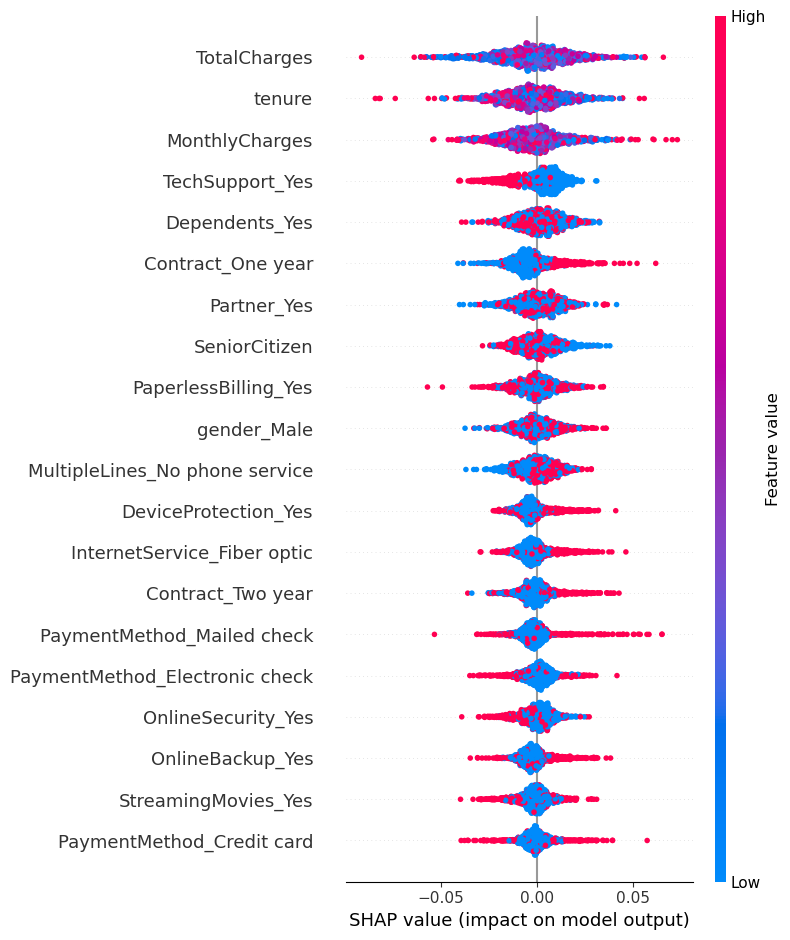

In [4]:
import shap

# Convert to float to avoid dtype('O') or boolean errors in SHAP
X_train_numeric = X_train.astype(float)
X_test_numeric = X_test.astype(float)

# Using the generic explainer with numeric data
explainer = shap.Explainer(model, X_train_numeric)
shap_values = explainer(X_test_numeric)

# shap_values[:, :, 1] selects the SHAP values for the positive class ('Yes')
shap.summary_plot(shap_values[:, :, 1], X_test_numeric)

In [5]:
import shap
# Initialize javascript for SHAP plots in notebook
shap.initjs()

# shap_values[0, :, 1] gets the explanation for the 1st instance, all features, for the positive class
shap.force_plot(
    shap_values[0, :, 1]
)

In [7]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train.values,
    feature_names=X.columns,
    class_names=["No Churn","Churn"],
    mode="classification"
)

exp = explainer.explain_instance(
    X_test.iloc[0].values,
    model.predict_proba,
    num_features=10
)
from IPython.display import display, HTML

display(HTML(exp.as_html()))

C:\Users\Shiva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [8]:
test_df = X_test.copy()
test_df["Actual"] = y_test
test_df["Predicted"] = pred

# Grouping by 'gender_Male' since 'gender' was one-hot encoded
bias_gender = test_df.groupby("gender_Male").apply(
    lambda x: (x["Predicted"] == x["Actual"]).mean(),
    include_groups=False
)

print("Accuracy by Gender (0 = Female, 1 = Male):")
print(bias_gender)

Accuracy by Gender (0 = Female, 1 = Male):
gender_Male
False    0.478417
True     0.514516
dtype: float64


In [9]:
test_df.groupby("gender_Male")["Predicted"].apply(lambda x: (x == "Yes").mean())

gender_Male
False    0.449640
True     0.443548
Name: Predicted, dtype: float64

In [10]:
from sklearn.metrics import confusion_matrix

def fpr(group):
    # confusion_matrix returns tn, fp, fn, tp for binary classification
    tn, fp, fn, tp = confusion_matrix(
        group["Actual"], group["Predicted"], labels=["No", "Yes"]
    ).ravel()
    return fp/(fp+tn)

# Using 'gender_Male' as the grouping column
test_df.groupby("gender_Male").apply(fpr, include_groups=False)

gender_Male
False    0.471831
True     0.426667
dtype: float64

In [11]:
test_df.groupby("SeniorCitizen")["Predicted"].apply(lambda x: (x == "Yes").mean())

SeniorCitizen
0    0.423588
1    0.470383
Name: Predicted, dtype: float64

In [12]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_res, y_res = sm.fit_resample(X_train, y_train)

In [13]:
print(classification_report(y_test, model.fit(X_res, y_res).predict(X_test)))

              precision    recall  f1-score   support

          No       0.49      0.54      0.51       584
         Yes       0.50      0.45      0.48       592

    accuracy                           0.50      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.50      0.50      0.49      1176



Background dataset has 4704 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4704 when initializing the masker.
100%|===================| 2350/2352 [04:53<00:00]        

Generating SHAP Global Summary Plot


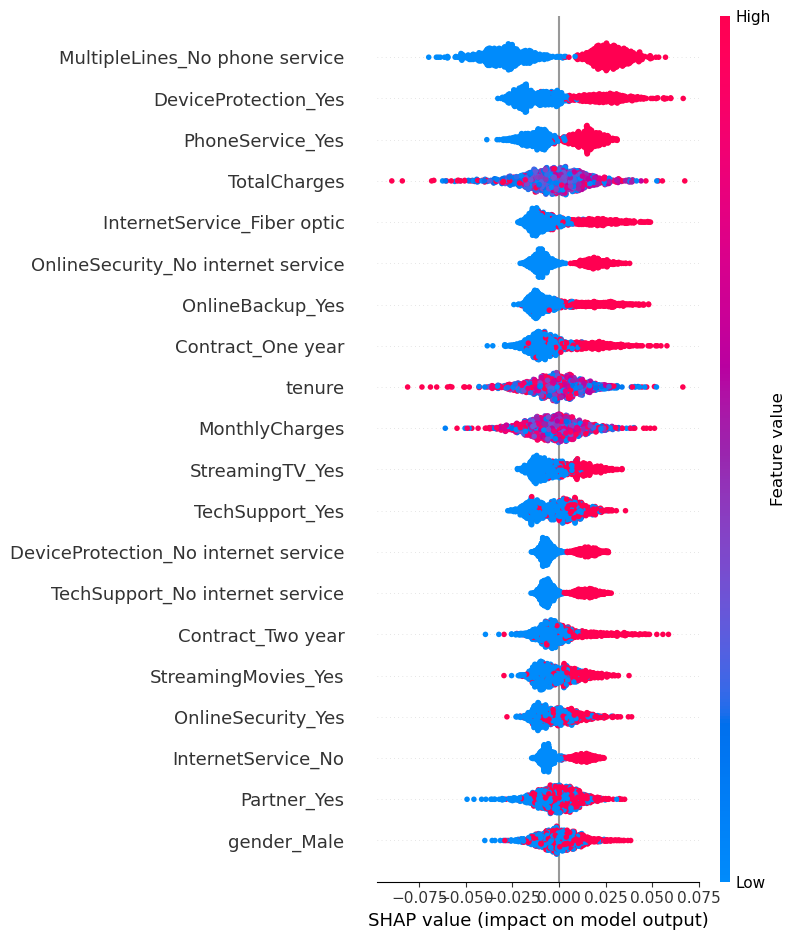

Generating SHAP Feature Impact Plot


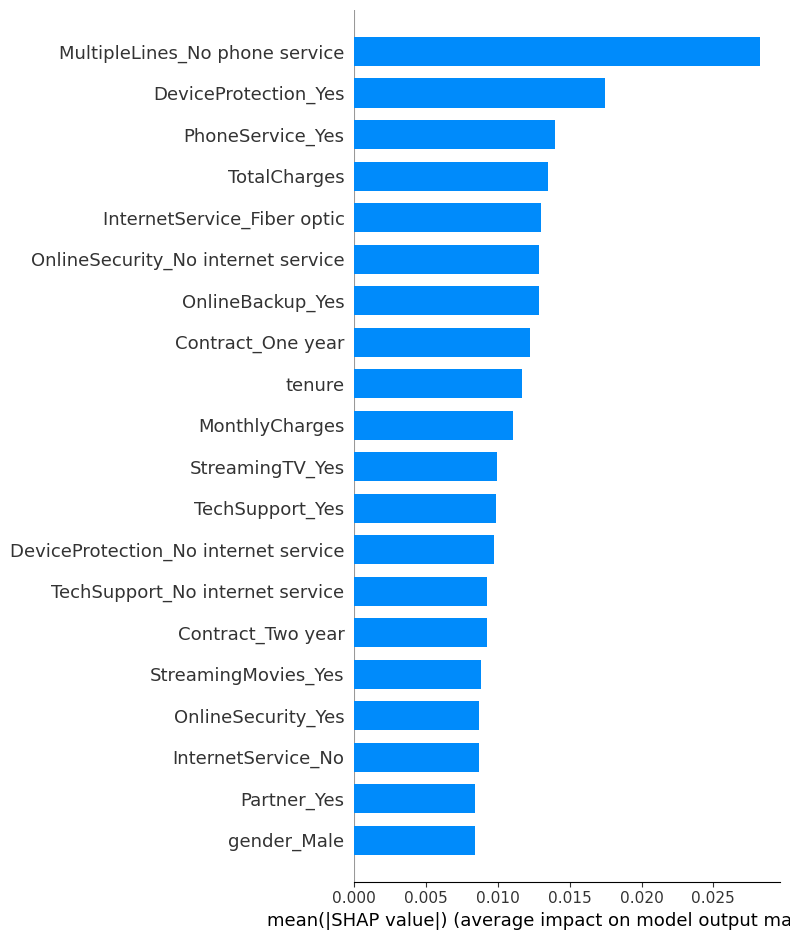


BIAS ANALYSIS BEFORE MITIGATION

Sensitive Attribute: gender_Male
   group  accuracy  false_positive_rate  true_positive_rate  prediction_rate
0  False  0.489209             0.471831            0.448529         0.460432
1   True  0.501613             0.453333            0.459375         0.456452

Sensitive Attribute: SeniorCitizen
   group  accuracy  false_positive_rate  true_positive_rate  prediction_rate
0      1  0.496516             0.503497            0.496528         0.500000
1      0  0.495017             0.422819            0.414474         0.418605

Applying SMOTE to balance training data

Model Performance After Mitigation
              precision    recall  f1-score   support

          No       0.49      0.53      0.51       584
         Yes       0.49      0.45      0.47       592

    accuracy                           0.49      1176
   macro avg       0.49      0.49      0.49      1176
weighted avg       0.49      0.49      0.49      1176



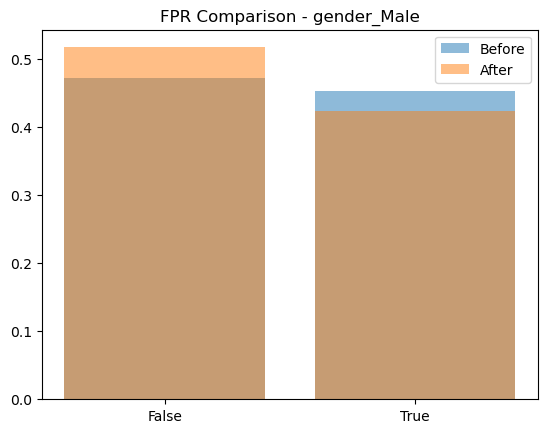

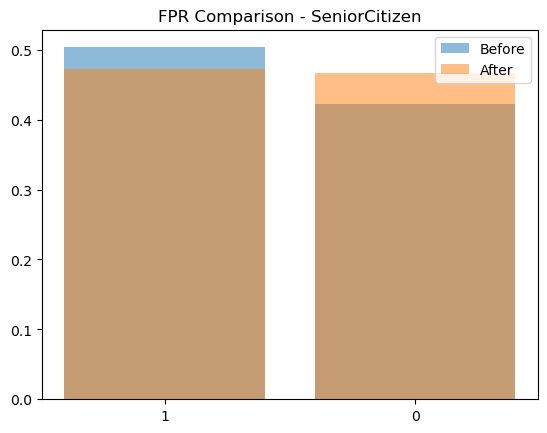

In [14]:
# =====================================================
# COMPLETE FAIRNESS + EXPLAINABILITY ANALYSIS
# =====================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Ensure data is numeric for SHAP
X_test_num = X_test.astype(float)

# -----------------------------------------------------
# 1. SHAP GLOBAL EXPLANATION
# -----------------------------------------------------

# Use the generic Explainer which is more robust for these metrics
explainer = shap.Explainer(model, X_train.astype(float))
shap_values = explainer(X_test_num)

print("Generating SHAP Global Summary Plot")
# Indexing [:, :, 1] selects the 'Churn=Yes' class
shap.summary_plot(shap_values[:, :, 1], X_test_num)

print("Generating SHAP Feature Impact Plot")
shap.summary_plot(shap_values[:, :, 1], X_test_num, plot_type="bar")

# -----------------------------------------------------
# 2. FAIRNESS METRIC FUNCTIONS
# -----------------------------------------------------

def compute_fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=["No", "Yes"]).ravel()
    return fp / (fp + tn) if (fp+tn)>0 else 0

def compute_tpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=["No", "Yes"]).ravel()
    return tp / (tp + fn) if (tp+fn)>0 else 0

# -----------------------------------------------------
# 3. BIAS CHECK BEFORE MITIGATION
# -----------------------------------------------------

print("\n==============================")
print("BIAS ANALYSIS BEFORE MITIGATION")
print("==============================")

baseline_pred = model.predict(X_test)

test_df = X_test.copy()
test_df["Actual"] = y_test.values
test_df["Predicted"] = baseline_pred

sensitive_features = [col for col in ["gender_Male", "SeniorCitizen"] if col in test_df.columns]

bias_results_before = {}

for feature in sensitive_features:
    print(f"\nSensitive Attribute: {feature}")
    results = []
    for group in test_df[feature].unique():
        subset = test_df[test_df[feature] == group]
        acc = (subset["Actual"] == subset["Predicted"]).mean()
        fpr_val = compute_fpr(subset["Actual"], subset["Predicted"])
        tpr_val = compute_tpr(subset["Actual"], subset["Predicted"])
        pred_rate = (subset["Predicted"] == "Yes").mean()
        results.append({"group": group, "accuracy": acc, "false_positive_rate": fpr_val, "true_positive_rate": tpr_val, "prediction_rate": pred_rate})
    bias_results_before[feature] = pd.DataFrame(results)
    print(bias_results_before[feature])

# -----------------------------------------------------
# 4. BIAS MITIGATION USING SMOTE
# -----------------------------------------------------

print("\nApplying SMOTE to balance training data")
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

fair_model = RandomForestClassifier(n_estimators=100, random_state=42)
fair_model.fit(X_res, y_res)
fair_pred = fair_model.predict(X_test)

print("\nModel Performance After Mitigation")
print(classification_report(y_test, fair_pred))

# -----------------------------------------------------
# 5. BIAS CHECK AFTER MITIGATION
# -----------------------------------------------------

test_df_after = X_test.copy()
test_df_after["Actual"] = y_test.values
test_df_after["Predicted"] = fair_pred
bias_results_after = {}

for feature in sensitive_features:
    results = []
    for group in test_df_after[feature].unique():
        subset = test_df_after[test_df_after[feature] == group]
        acc = (subset["Actual"] == subset["Predicted"]).mean()
        fpr_val = compute_fpr(subset["Actual"], subset["Predicted"])
        tpr_val = compute_tpr(subset["Actual"], subset["Predicted"])
        pred_rate = (subset["Predicted"] == "Yes").mean()
        results.append({"group": group, "accuracy": acc, "false_positive_rate": fpr_val, "true_positive_rate": tpr_val, "prediction_rate": pred_rate})
    bias_results_after[feature] = pd.DataFrame(results)

# -----------------------------------------------------
# 6. VISUALIZATION
# -----------------------------------------------------
for feature in sensitive_features:
    plt.figure()
    plt.bar(bias_results_before[feature]["group"].astype(str), bias_results_before[feature]["false_positive_rate"], alpha=0.5, label="Before")
    plt.bar(bias_results_after[feature]["group"].astype(str), bias_results_after[feature]["false_positive_rate"], alpha=0.5, label="After")
    plt.title(f"FPR Comparison - {feature}")
    plt.legend()
    plt.show()

In [15]:
pip install pandas numpy scikit-learn matplotlib shap lime imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


### Required Libraries Summary:
- **pandas & numpy**: Data manipulation and numerical operations.
- **scikit-learn**: Model building (Random Forest) and evaluation metrics.
- **matplotlib**: Basic data visualization.
- **shap**: Global and local model explainability.
- **lime**: Local interpretable model-agnostic explanations.
- **imbalanced-learn (imblearn)**: SMOTE technique for handling class imbalance and bias mitigation.